In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import MeanAbsoluteError

# Carga de datos

In [2]:
REPO_NAME = "AA-II-RodriguezyBarros-Herrera-Zahradnicek"
BRANCH_NAME = "Problema_1"

if REPO_NAME not in os.getcwd():
  if not os.path.exists(REPO_NAME):
    !git clone -b {BRANCH_NAME} https://github.com/franciscoryb1/{REPO_NAME}.git
  os.chdir(REPO_NAME)


Cloning into 'AA-II-RodriguezyBarros-Herrera-Zahradnicek'...
remote: Enumerating objects: 24330, done.
remote: Total 24330 (delta 0), reused 0 (delta 0), pack-reused 24330 (from 2)
Receiving objects: 100% (24330/24330), 393.04 MiB | 27.43 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [3]:
file_path = "/content/AA-II-RodriguezyBarros-Herrera-Zahradnicek/Student_Performance.csv"
# file_path = "Student_Performance.csv"

df = pd.read_csv(file_path, sep=",", engine="python")
df.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


### Características de entrada:

* Hours Studied: El número total de horas dedicadas al estudio por cada estudiante.

* Previous Scores: Las puntuaciones obtenidas por los estudiantes en exámenes previos.
* Extracurricular Activities: Si el estudiante participa en actividades extracurriculares (Sí o
No).
* Sleep Hours: El número promedio de horas de sueño que el estudiante tuvo por día.
* Sample Question Papers Practiced: El número de cuestionarios de muestra que el estudiante
practicó.
Además, el dataset incluye la variable objetivo:

### Variable de salida (target):

* Performance Index: Un índice que representa el rendimiento académico general de cada
estudiante, redondeado al entero más cercano. Este índice varía de 10 a 100, donde valores
más altos indican un mejor rendimiento.

# Análisis exploratorio de datos

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


No tenemos valores faltantes en nuestro dataset.

In [6]:
df.describe(include='all')

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,No,NaN,NaN,NaN
freq,NaN,NaN,5052,NaN,NaN,NaN
mean,4.992900,69.445700,NaN,6.530600,4.583300,55.224800
std,2.589309,17.343152,NaN,1.695863,2.867348,19.212558
min,1.000000,40.000000,NaN,4.000000,0.000000,10.000000
25%,3.000000,54.000000,NaN,5.000000,2.000000,40.000000
50%,5.000000,69.000000,NaN,7.000000,5.000000,55.000000
75%,7.000000,85.000000,NaN,8.000000,7.000000,71.000000


## Matriz de correlacion

In [7]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

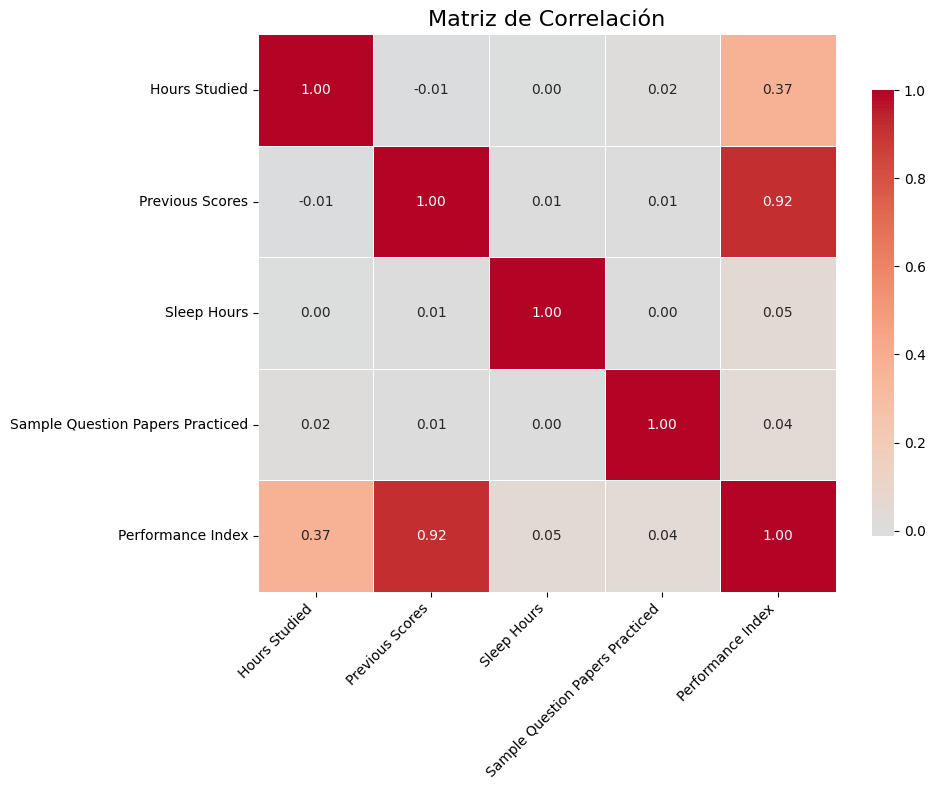

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suponiendo que tus datos están en un DataFrame llamado 'df'
# Si no, primero carga tus datos: df = pd.read_csv('tudataset.csv')

# Seleccionar solo las columnas numéricas para la matriz de correlación
numeric_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
                'Sample Question Papers Practiced', 'Performance Index']

# Calcular la matriz de correlación
corr_matrix = df[numeric_cols].corr()

# Configurar el estilo del gráfico
plt.figure(figsize=(10, 8))
plt.title('Matriz de Correlación', fontsize=16)

# Crear el heatmap usando seaborn (que se basa en matplotlib)
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

# Rotar las etiquetas del eje x para mejor legibilidad
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

No se aprecian fuertes correlaciones entre las variables numericas de nuestro dataset, la mas alta (0.37) resulta ser la correlacion entre **Horas estudiadas** y la variable target **Performance Index** pero, igualmente, es un numero bajo.

# Hours Studied

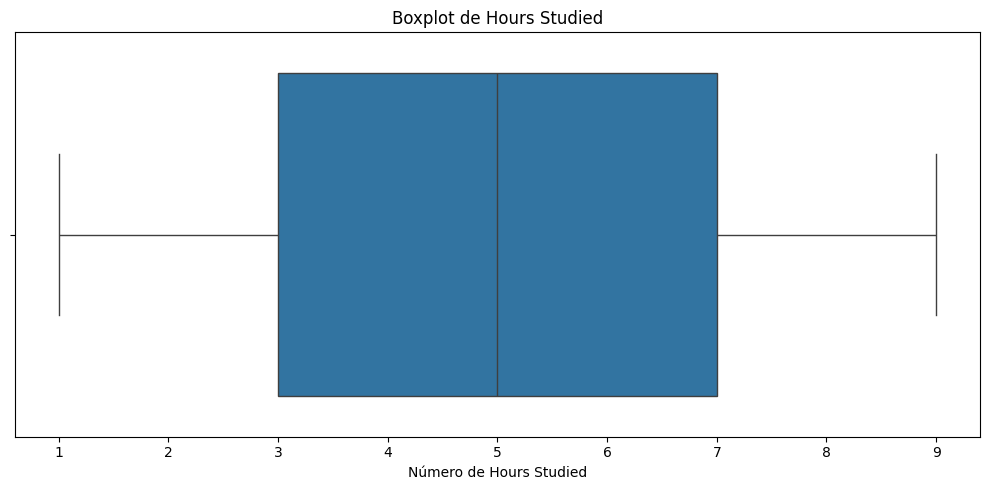

,Hours Studied
count,10000.000000
mean,4.992900
std,2.589309
min,1.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,9.000000


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el gráfico de boxplot y personalizar los casos atípicos
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Hours Studied'],
            flierprops=dict(marker='o', color='red', markersize=8))

# Título y etiquetas
plt.title('Boxplot de Hours Studied')
plt.xlabel('Número de Hours Studied')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Descripción estadística de 'Hours Studied'
df['Hours Studied'].describe()


La mayoría de los datos de la variable **Hours Studied** se encuentran entre 3 y 7 horas de estudio, con una mediana cerca de las 5 horas y no se observan valores atípicos.

## Previous Scores

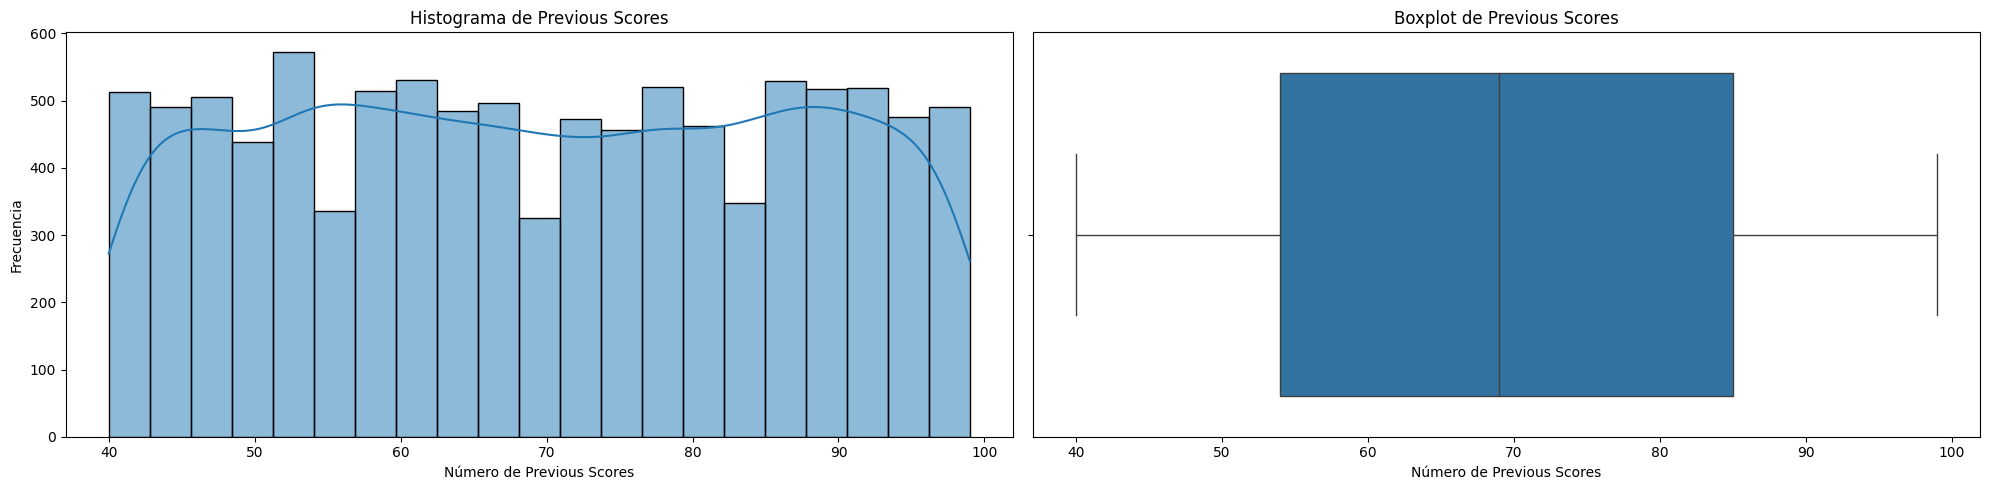

,Previous Scores
count,10000.000000
mean,69.445700
std,17.343152
min,40.000000
25%,54.000000
50%,69.000000
75%,85.000000
max,99.000000


In [20]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

# Histograma
sns.histplot(df['Previous Scores'], kde=True, ax=axs[0])
axs[0].set_title('Histograma de Previous Scores')
axs[0].set_xlabel('Número de Previous Scores')
axs[0].set_ylabel('Frecuencia')

# Calcular cuartiles
q1 = df['Previous Scores'].quantile(0.25)
q2 = df['Previous Scores'].quantile(0.5)
q3 = df['Previous Scores'].quantile(0.75)

# Boxplot
sns.boxplot(x=df['Previous Scores'], ax=axs[1])
axs[1].set_title('Boxplot de Previous Scores')
axs[1].set_xlabel('Número de Previous Scores')

plt.tight_layout()
plt.show()

df['Previous Scores'].describe()

En la variable **Previous Scores** la mayoría de los puntajes están entre 54 y 85, con una mediana cerca de 69, sin valores atípicos.

## Extracurricular Activities

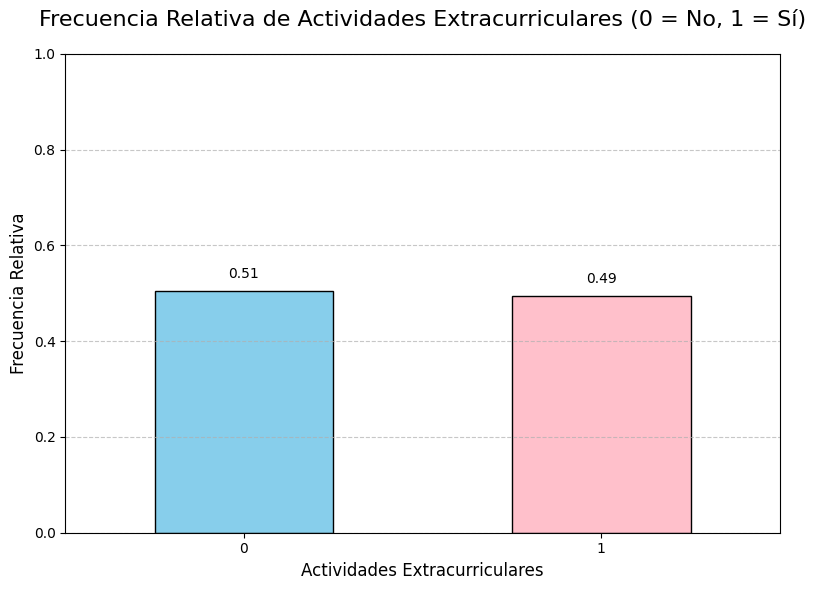

In [9]:
import matplotlib.pyplot as plt

# Gráfico para visualizar el balance de 'Extracurricular Activities'
rel_freq = df['Extracurricular Activities'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8, 6))
grafico = rel_freq.plot(
    kind='bar',
    color=['skyblue', 'pink'],
    edgecolor='black'
)

# Títulos y etiquetas
plt.title('Frecuencia Relativa de Actividades Extracurriculares (0 = No, 1 = Sí)', fontsize=16, pad=20)
plt.xlabel('Actividades Extracurriculares', fontsize=12)
plt.ylabel('Frecuencia Relativa', fontsize=12)
plt.ylim(0, 1)  # Para que las barras no se corten

# Etiquetas arriba de las barras
for index, value in enumerate(rel_freq):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Sleep Hours

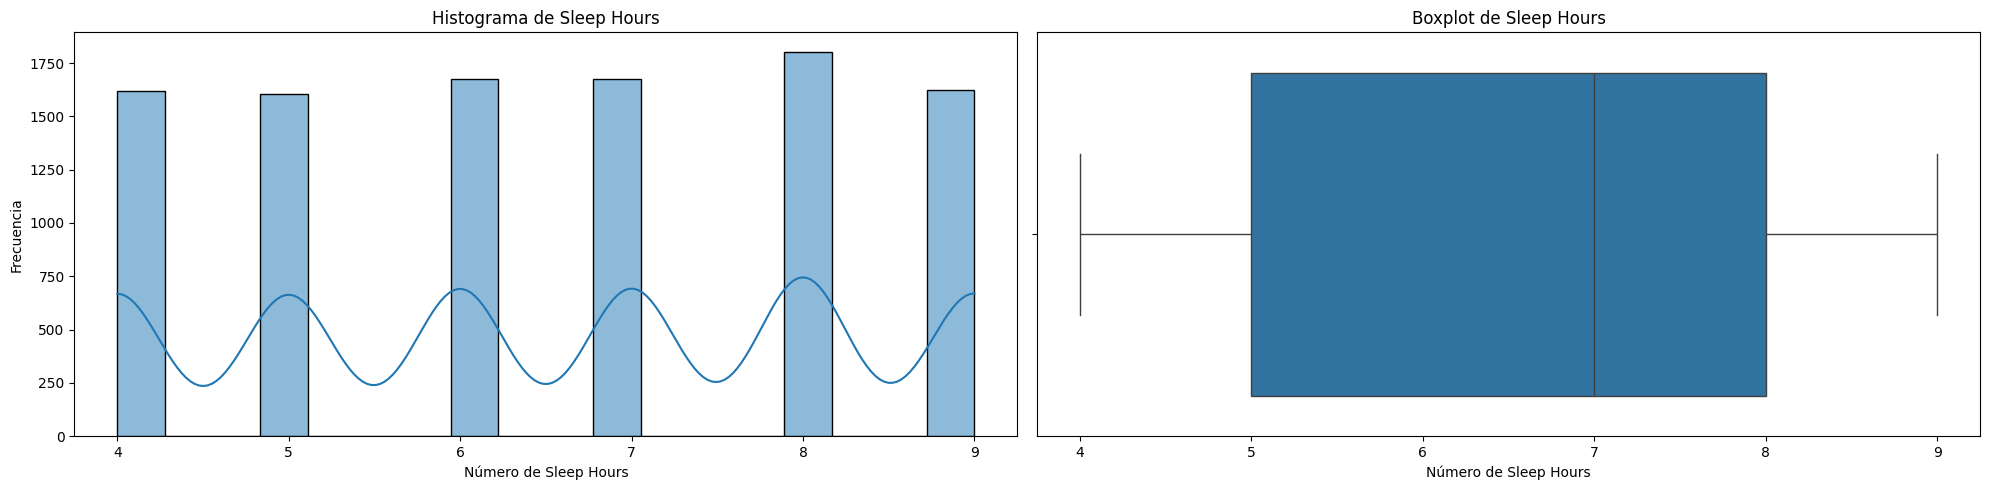

,Sleep Hours
count,10000.000000
mean,6.530600
std,1.695863
min,4.000000
25%,5.000000
50%,7.000000
75%,8.000000
max,9.000000


In [21]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

# Histograma
sns.histplot(df['Sleep Hours'], kde=True, ax=axs[0])
axs[0].set_title('Histograma de Sleep Hours')
axs[0].set_xlabel('Número de Sleep Hours')
axs[0].set_ylabel('Frecuencia')

# Calcular cuartiles
q1 = df['Sleep Hours'].quantile(0.25)
q2 = df['Sleep Hours'].quantile(0.5)
q3 = df['Sleep Hours'].quantile(0.75)

# Boxplot
sns.boxplot(x=df['Sleep Hours'], ax=axs[1])
axs[1].set_title('Boxplot de Sleep Hours')
axs[1].set_xlabel('Número de Sleep Hours')

plt.tight_layout()
plt.show()

df['Sleep Hours'].describe()

El boxplot de Sleep Hours muestra que la mayoría de los datos están entre 5 y 8 horas de sueño, sin valores atípicos.

## Sample Question Papers Practiced

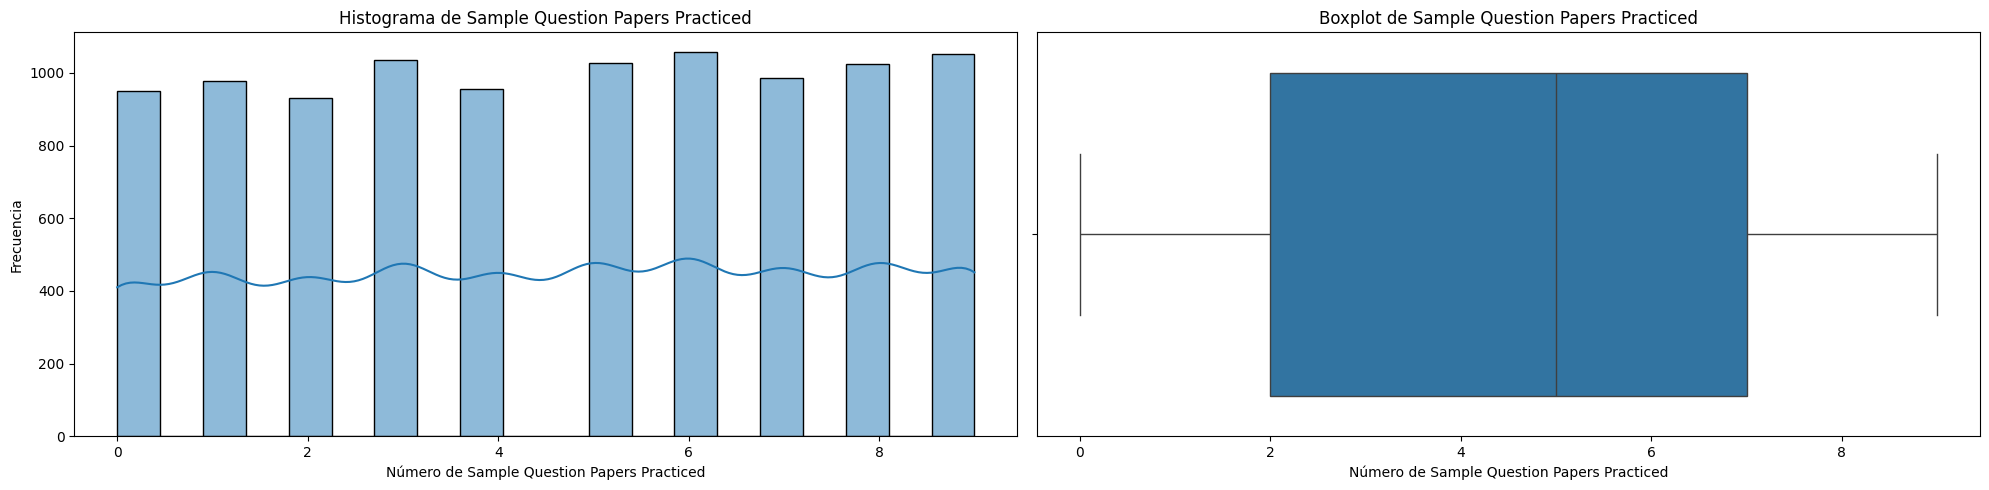

,Sample Question Papers Practiced
count,10000.000000
mean,4.583300
std,2.867348
min,0.000000
25%,2.000000
50%,5.000000
75%,7.000000
max,9.000000


In [22]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))

# Histograma
sns.histplot(df['Sample Question Papers Practiced'], kde=True, ax=axs[0])
axs[0].set_title('Histograma de Sample Question Papers Practiced')
axs[0].set_xlabel('Número de Sample Question Papers Practiced')
axs[0].set_ylabel('Frecuencia')

# Calcular cuartiles
q1 = df['Sample Question Papers Practiced'].quantile(0.25)
q2 = df['Sample Question Papers Practiced'].quantile(0.5)
q3 = df['Sample Question Papers Practiced'].quantile(0.75)

# Boxplot
sns.boxplot(x=df['Sample Question Papers Practiced'], ax=axs[1])
axs[1].set_title('Boxplot de Sample Question Papers Practiced')
axs[1].set_xlabel('Número de Sample Question Papers Practiced')

plt.tight_layout()
plt.show()

df['Sample Question Papers Practiced'].describe()

En la variable **Sample Question Papers Practiced** la mayoría de los datos están entre 2 y 7 cuestionarios practicados, con una mediana cerca de 5, sin valores atípicos.

# Split de datos

In [10]:
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Modelos

In [23]:
# Construcción del modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # Salida para regresión
])

# Compilación con MAE como métrica
model.compile(optimizer='adam', loss='mean_absolute_error', metrics=[MeanAbsoluteError()])

# Callback para detener cuando no mejora la validación
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenamiento con validación
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 47.7890 - mean_absolute_error: 47.7890 - val_loss: 7.1027 - val_mean_absolute_error: 7.1027
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.8204 - mean_absolute_error: 5.8204 - val_loss: 4.1962 - val_mean_absolute_error: 4.1962
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8091 - mean_absolute_error: 3.8091 - val_loss: 2.7364 - val_mean_absolute_error: 2.7364
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.4448 - mean_absolute_error: 2.4448 - val_loss: 1.8311 - val_mean_absolute_error: 1.8311
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.8276 - mean_absolute_error: 1.8276 - val_loss: 1.6969 - val_mean_absolute_error: 1.6969
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7670 - mean_absolute_error: 1.7670 - val_loss: 1.6611 - val_mean_absolute_error: 1.6611
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7426 - mean_absolute_error: 1.7426 - val

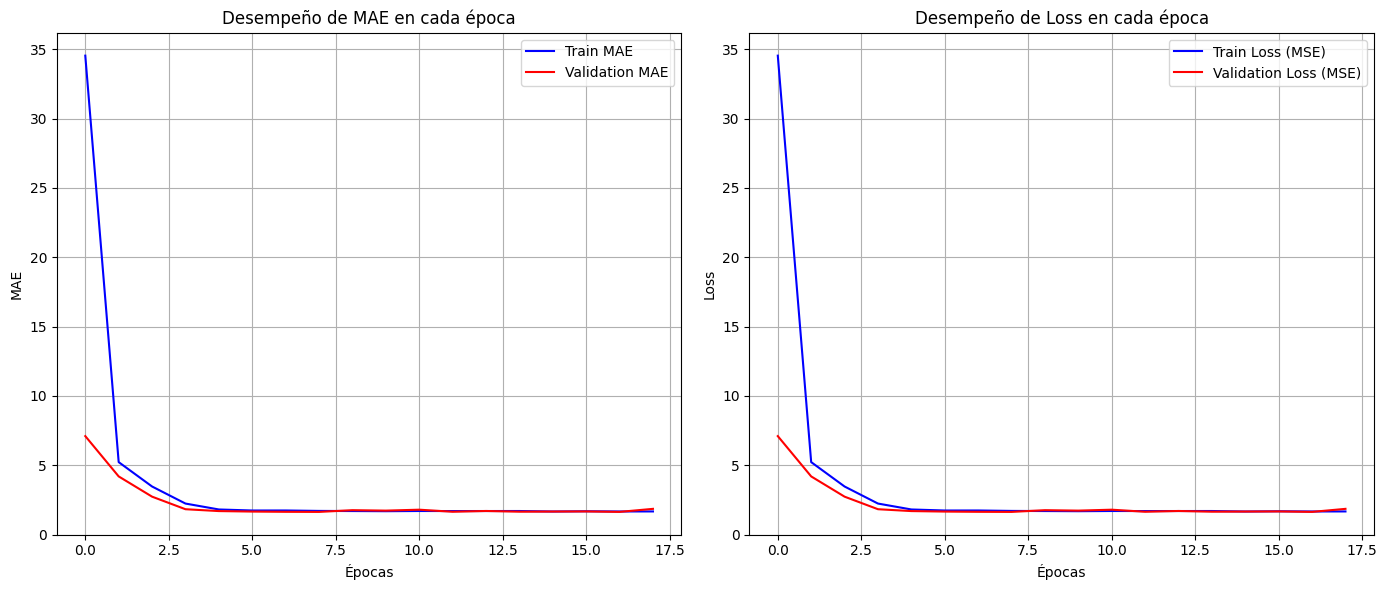

In [25]:
import matplotlib.pyplot as plt

# Obtener el historial del entrenamiento
history_dict = history.history

# Crear una figura con dos subgráficas
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Graficar MAE en entrenamiento y validación en la primera subgráfica
axs[0].plot(history_dict['mean_absolute_error'], label='Train MAE', color='blue')
axs[0].plot(history_dict['val_mean_absolute_error'], label='Validation MAE', color='red')
axs[0].set_title('Desempeño de MAE en cada época')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('MAE')
axs[0].legend()
axs[0].grid(True)

# Graficar Loss (MSE) en entrenamiento y validación en la segunda subgráfica
axs[1].plot(history_dict['loss'], label='Train Loss (MSE)', color='blue')
axs[1].plot(history_dict['val_loss'], label='Validation Loss (MSE)', color='red')
axs[1].set_title('Desempeño de Loss en cada época')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

# Mostrar el gráfico
plt.tight_layout()
plt.show()
